# Late Fusion Pipeline (Phase 2a)

**Goal**: Combine R-GCN graph scores with text embedding cosine similarity scores.

`s_final(d) = β · s_graph(d) + (1-β) · s_LLM(d)`

**Pipeline**:
1. Generate Tier 1 + Tier 2 descriptions from PrimeKG metadata
2. Encode Tier 2 with 4 encoders × 4 projections → select best combo by proxy MRR
3. (Optional) GPT-4o enrichment with best encoder
4. Full late fusion: beta sweep with 5-fold CV → evaluate on test diseases

## 0. Setup

In [1]:
!pip install -q transformers adapters torch torch-geometric wandb scikit-learn openai scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 113.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 22.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
PROJECT = "/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702"
sys.path.insert(0, PROJECT)
%cd {PROJECT}

In [4]:
import json
import logging
import numpy as np
import pandas as pd
import torch

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


---
## 1. Generate Descriptions (Tier 1 + Tier 2)

In [ ]:
!ls data/primekg/

In [ ]:
# Generate Tier 2 descriptions (name + 1-hop KG context)
!python scripts/generate_descriptions.py \
    --data-dir data/primekg \
    --split-dir data/splits \
    --output-dir data/descriptions \
    --tier tier2

INFO: Loading PrimeKG...
/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/scripts/generate_descriptions.py:420: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg_df = pd.read_csv(data_dir / "kg.csv")
INFO: Loaded 129375 nodes, 8100498 edges
INFO: Split: 431 train, 108 test diseases
INFO: Phenotypes associated with eligible diseases: 3518
INFO: Building tier2 drug descriptions...
INFO: Built 7957 drug descriptions
INFO: Building tier2 phenotype descriptions...
INFO: Built 3518 phenotype descriptions
INFO: Saved: data/descriptions/drugs_tier2.json (7957 drugs)
INFO: Saved: data/descriptions/phenotypes_tier2.json (3518 phenotypes)
INFO: Sample drug description: Copper. Targets: A1BG, A2M, ACTG1, ACTN1, ACY1, AFM, AGT, AHCY, AHSG, AKR1A1.
INFO: Sample phenotype description: Growth abnormality. Associated genes: TET3, ZMIZ1, ZNF292. Associated conditions: Andersen-Tawil syndrome, CHIME syndrome, Czech dysplasia, metatarsal type,

In [ ]:
# Generate Tier 1 descriptions (name only, for ablation)
!python scripts/generate_descriptions.py \
    --data-dir data/primekg \
    --split-dir data/splits \
    --output-dir data/descriptions \
    --tier tier1

INFO: Loading PrimeKG...
['edges.csv', 'nodes.csv', 'kg.csv']
/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/scripts/generate_descriptions.py:422: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg_df = pd.read_csv(data_dir / "kg.csv")
INFO: Loaded 129375 nodes, 8100498 edges
INFO: Split: 431 train, 108 test diseases
INFO: Phenotypes associated with eligible diseases: 3518
INFO: Building tier1 drug descriptions...
INFO: Built 7957 drug descriptions
INFO: Building tier1 phenotype descriptions...
INFO: Built 3518 phenotype descriptions
INFO: Saved: data/descriptions/drugs_tier1.json (7957 drugs)
INFO: Saved: data/descriptions/phenotypes_tier1.json (3518 phenotypes)
INFO: Sample drug description: Copper
INFO: Sample phenotype description: Growth abnormality


In [ ]:
# Verify
for tier in ["tier1", "tier2"]:
    for entity in ["drugs", "phenotypes"]:
        path = f"data/descriptions/{entity}_{tier}.json"
        with open(path) as f:
            data = json.load(f)
        sample = next(iter(data.values()))
        print(f"{entity}_{tier}: {len(data)} entries")
        print(f"  Sample: {sample['text'][:120]}...\n")

drugs_tier1: 7957 entries
  Sample: Copper...

phenotypes_tier1: 3518 entries
  Sample: Growth abnormality...

drugs_tier2: 7957 entries
  Sample: Copper. Targets: A1BG, A2M, ACTG1, ACTN1, ACY1, AFM, AGT, AHCY, AHSG, AKR1A1....

phenotypes_tier2: 3518 entries
  Sample: Growth abnormality. Associated genes: TET3, ZMIZ1, ZNF292. Associated conditions: Andersen-Tawil syndrome, CHIME syndrom...



---
## 2. Encoder + Projection Selection

Encode Tier 2 descriptions with all 4 encoders × 4 projections, then pick the best combo by proxy MRR on training diseases.

In [ ]:
# Encode all 16 combos (4 encoders × 4 projections)
# This takes ~20-40 min total. To save time, start with just pca + none.

encoders = ["pubmedbert", "biolinkbert", "biomedbert", "specter2"]
#encoders = ["specter2"]
#encoders = ["biomedbert"]
projections = ["pca", "none", "linear", "nonlinear_ae"]

for enc in encoders:
    for proj in projections:
        print(f"\n{'='*60}")
        print(f"Encoding: {enc} / {proj}")
        print(f"{'='*60}")
        !python scripts/cache_embeddings.py \
            --desc-dir data/descriptions \
            --output-dir data/embeddings \
            --encoder {enc} \
            --tier tier2 \
            --projection {proj} \
            --device cuda

In [ ]:
# Compute proxy MRR for each combo
from src.data.primekg_loader import load_primekg, build_supervision_maps
from src.data.disease_split import load_split
from src.evaluation.late_fusion_eval import load_llm_scores
from src.evaluation.metrics import reciprocal_rank

nodes_df, edges_df, kg_df = load_primekg("data/primekg")
train_diseases, test_diseases, train_pairs, test_pairs = load_split("data/splits")
supervision = build_supervision_maps(
    kg_df, nodes_df, train_diseases, test_diseases, train_pairs, test_pairs
)
disease_to_phenotypes = supervision["disease_to_phenotypes"]
train_disease_to_drugs = supervision["train_disease_to_drugs"]
drug_indices_arr = np.array(sorted(supervision["drug_indices"]))

print(f"Train diseases: {len(train_diseases)}")
print(f"Test diseases: {len(test_diseases)}")
print(f"Drug nodes: {len(drug_indices_arr)}")

/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Train diseases: 431
Test diseases: 108
Drug nodes: 7957


In [ ]:
selection_results = []
encoders = ["pubmedbert", "biolinkbert", "biomedbert", "specter2"]
projections = ["pca", "none", "linear", "nonlinear_ae"]

for enc in encoders:
    for proj in projections:
        drug_path = f"data/embeddings/{enc}/tier2/{proj}/drug_embeddings.pt"
        pheno_path = f"data/embeddings/{enc}/tier2/{proj}/phenotype_embeddings.pt"

        try:
            llm_scores = load_llm_scores(
                train_diseases, disease_to_phenotypes, drug_path, pheno_path
            )
        except FileNotFoundError:
            print(f"  {enc}/{proj}: SKIPPED (not cached)")
            continue

        mrrs = []
        for d_idx, scores in llm_scores.items():
            true_drugs = list(train_disease_to_drugs.get(d_idx, []))
            if not true_drugs:
                continue
            ranked = drug_indices_arr[np.argsort(-scores)].tolist()
            mrrs.append(reciprocal_rank(ranked, true_drugs))

        proxy_mrr = np.mean(mrrs) if mrrs else 0.0
        selection_results.append({"encoder": enc, "projection": proj, "proxy_MRR": proxy_mrr})
        print(f"  {enc}/{proj}: proxy MRR = {proxy_mrr:.4f} ({len(mrrs)} diseases)")

selection_df = pd.DataFrame(selection_results).sort_values("proxy_MRR", ascending=False)
print("\n=== Encoder + Projection Ranking ===")
print(selection_df.to_string(index=False))

  pubmedbert/pca: proxy MRR = 0.1948 (431 diseases)
  pubmedbert/none: proxy MRR = 0.2264 (431 diseases)
  pubmedbert/linear: proxy MRR = 0.1825 (431 diseases)
  pubmedbert/nonlinear_ae: proxy MRR = 0.2303 (431 diseases)
  biolinkbert/pca: proxy MRR = 0.1965 (431 diseases)
  biolinkbert/none: proxy MRR = 0.2083 (431 diseases)
  biolinkbert/linear: proxy MRR = 0.2038 (431 diseases)
  biolinkbert/nonlinear_ae: proxy MRR = 0.2622 (431 diseases)
  biomedbert/pca: proxy MRR = 0.1955 (431 diseases)
  biomedbert/none: proxy MRR = 0.2022 (431 diseases)
  biomedbert/linear: proxy MRR = 0.1895 (431 diseases)
  biomedbert/nonlinear_ae: proxy MRR = 0.1700 (431 diseases)
  specter2/pca: proxy MRR = 0.2153 (431 diseases)
  specter2/none: proxy MRR = 0.2138 (431 diseases)
  specter2/linear: proxy MRR = 0.2085 (431 diseases)
  specter2/nonlinear_ae: proxy MRR = 0.2135 (431 diseases)

=== Encoder + Projection Ranking ===
    encoder   projection  proxy_MRR
biolinkbert nonlinear_ae   0.262170
 pubmedber

In [ ]:
# Select the best combo
best_row = selection_df.iloc[0]
BEST_ENCODER = best_row["encoder"]
BEST_PROJECTION = best_row["projection"]

print(f"*** Best encoder:    {BEST_ENCODER}")
print(f"*** Best projection: {BEST_PROJECTION}")
print(f"*** Proxy MRR:       {best_row['proxy_MRR']:.4f}")

*** Best encoder:    biolinkbert
*** Best projection: nonlinear_ae
*** Proxy MRR:       0.2622


---
## 3. Tier 1 vs Tier 2 Ablation (Optional)

Compare proxy MRR of Tier 1 (name only) vs Tier 2 (name + KG context) with the best encoder.

In [ ]:
BEST_ENCODER = "biolinkbert"
BEST_PROJECTION = "nonlinear_ae"

In [ ]:
# Encode Tier 1 with the best combo
!python scripts/cache_embeddings.py \
    --desc-dir data/descriptions \
    --output-dir data/embeddings \
    --encoder {BEST_ENCODER} \
    --tier tier1 \
    --projection {BEST_PROJECTION} \
    --device cuda

INFO: Encoder: biolinkbert (michiyasunaga/BioLinkBERT-base)
INFO: Pooling: mean
INFO: Tier: tier1, Projection: nonlinear_ae
INFO: Seed: 42
INFO: Loading drugs descriptions from data/descriptions/drugs_tier1.json
INFO: Loaded 7957 drugs descriptions
INFO: Encoding drugs with biolinkbert...
INFO: NumExpr defaulting to 8 threads.
tokenizer_config.json: 100% 379/379 [00:00<00:00, 2.85MB/s]
vocab.txt: 225kB [00:00, 61.5MB/s]
tokenizer.json: 447kB [00:00, 93.6MB/s]
special_tokens_map.json: 100% 112/112 [00:00<00:00, 867kB/s]
config.json: 100% 559/559 [00:00<00:00, 5.04MB/s]
2026-04-22 07:43:34.466671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776843814.487252    7895 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776843814.493403    7895 cu

In [ ]:
# Tier 1 proxy MRR
drug_path_t1 = f"data/embeddings/{BEST_ENCODER}/tier1/{BEST_PROJECTION}/drug_embeddings.pt"
pheno_path_t1 = f"data/embeddings/{BEST_ENCODER}/tier1/{BEST_PROJECTION}/phenotype_embeddings.pt"

llm_scores_t1 = load_llm_scores(
    train_diseases, disease_to_phenotypes, drug_path_t1, pheno_path_t1
)

mrrs_t1 = []
for d_idx, scores in llm_scores_t1.items():
    true_drugs = list(train_disease_to_drugs.get(d_idx, []))
    if not true_drugs:
        continue
    ranked = drug_indices_arr[np.argsort(-scores)].tolist()
    mrrs_t1.append(reciprocal_rank(ranked, true_drugs))

tier1_mrr = np.mean(mrrs_t1)
tier2_mrr = best_row["proxy_MRR"]

print(f"Tier 1 (name only)    proxy MRR: {tier1_mrr:.4f}")
print(f"Tier 2 (name + KG)    proxy MRR: {tier2_mrr:.4f}")
print(f"Delta (Tier2 - Tier1):           {tier2_mrr - tier1_mrr:+.4f}")

Tier 1 (name only)    proxy MRR: 0.0160
Tier 2 (name + KG)    proxy MRR: 0.2622
Delta (Tier2 - Tier1):           +0.2462


---
## 4. GPT-4o Description Enrichment

Enrich Tier 2 descriptions with GPT-4o. **Cost: ~$20.** Skip if you want to test fusion with Tier 2 first.

In [ ]:
import os
import getpass

if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter OPENAI_API_KEY: ")
print("OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))


Enter OPENAI_API_KEY: ··········
OPENAI_API_KEY set: True


In [ ]:
# Quick dry-run on ~10 samples before full GPT-4o enrichment
import json
import random
from openai import OpenAI
from scripts.generate_descriptions import DRUG_PROMPT, PHENOTYPE_PROMPT

client = OpenAI()
rng = random.Random(42)

with open("data/descriptions/drugs_tier2.json") as f:
    drug_desc = json.load(f)
with open("data/descriptions/phenotypes_tier2.json") as f:
    pheno_desc = json.load(f)

sample_drugs = rng.sample(list(drug_desc.items()), k=min(5, len(drug_desc)))
sample_phenos = rng.sample(list(pheno_desc.items()), k=min(5, len(pheno_desc)))

def _preview(item, entity_type):
    idx, entry = item
    prompt = (DRUG_PROMPT if entity_type == "drug" else PHENOTYPE_PROMPT).format(
        tier2_text=entry["text"]
    )
    resp = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=120,
    )
    text = resp.choices[0].message.content.strip().replace("\n", " ")
    print(f"[{entity_type}:{idx}] {entry['name']} -> {text[:180]}...")

for item in sample_drugs:
    _preview(item, "drug")
for item in sample_phenos:
    _preview(item, "phenotype")

print("Sample check complete. If outputs look good, set RUN_FULL_GPT4O=True in the next cell.")


[drug:19250] Pentostatin -> Pentostatin is an antineoplastic agent that functions as an adenosine deaminase (ADA) inhibitor, leading to the accumulation of deoxyadenosine triphosphate, which is toxic to lymph...
[drug:14924] Diazoxide -> Diazoxide is a potassium channel opener that primarily acts by activating K_ATP channels, particularly targeting the KCNJ11 subunit, leading to hyperpolarization of pancreatic beta...
[drug:14216] Warfarin -> Warfarin is an anticoagulant that functions by inhibiting the vitamin K epoxide reductase complex 1 (VKORC1), leading to a reduction in the synthesis of active clotting factors II,...
[drug:20086] Alpha-Methylisocitric Acid -> Alpha-Methylisocitric Acid is a metabolic compound that targets aconitase 2 (ACO2), an enzyme involved in the citric acid cycle. By inhibiting ACO2, it disrupts the conversion of c...
[drug:16265] Soybean oil -> Soybean oil is a natural lipid that primarily targets the peroxisome proliferator-activated receptor alpha (PPARA)

In [ ]:
# (Optional) Faster GPT-4o enrichment: concurrent requests + 429 backoff
# This is an alternative to running scripts/generate_descriptions.py --use-llm (which is serial).

import asyncio
import json
import os
import random
import time

from openai import AsyncOpenAI

try:
    from openai import RateLimitError, APIError, APITimeoutError, APIConnectionError
except Exception:  # older SDKs
    RateLimitError = APIError = APITimeoutError = APIConnectionError = Exception

from scripts.generate_descriptions import DRUG_PROMPT, PHENOTYPE_PROMPT

async_client = AsyncOpenAI()


async def _call_with_backoff(*, prompt: str, model: str, max_retries: int = 8, base_delay_s: float = 0.5, max_delay_s: float = 30.0):
    """Call the API with exponential backoff (+ jitter) on transient failures (429/5xx/timeouts)."""
    for attempt in range(max_retries):
        try:
            resp = await async_client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3,
                max_tokens=200,
            )
            return resp.choices[0].message.content.strip()
        except (RateLimitError, APITimeoutError, APIConnectionError, APIError):
            if attempt >= max_retries - 1:
                raise
            sleep_s = min(max_delay_s, base_delay_s * (2 ** attempt))
            sleep_s *= 0.5 + random.random()  # jitter in [0.5, 1.5)
            await asyncio.sleep(sleep_s)


async def enrich_json_concurrent(
    *,
    input_path: str,
    output_path: str,
    entity_type: str,
    model: str = "gpt-4o",
    max_in_flight: int = 20,
    checkpoint_every: int = 50,
):
    """Concurrent, resumable enrichment that writes the same JSON format as scripts/generate_descriptions.py.

    Resume policy: rows already in `output_path` are skipped UNLESS they have
    an '_error' field — those are treated as not-done and re-attempted, so
    topping up the API quota and re-running this cell will retry only the
    contaminated rows.
    """
    assert entity_type in {"drug", "phenotype"}
    prompt_template = DRUG_PROMPT if entity_type == "drug" else PHENOTYPE_PROMPT

    with open(input_path) as f:
        base = json.load(f)  # {str(node_idx): {name,text}}

    enriched = {}
    if os.path.exists(output_path):
        with open(output_path) as f:
            enriched = json.load(f)
        n_failed = sum(1 for v in enriched.values() if "_error" in v)
        n_ok = len(enriched) - n_failed
        print(
            f"Resuming {entity_type}: {n_ok} ok, {n_failed} previously failed (will retry), "
            f"{len(base) - n_ok - n_failed} never attempted"
        )

    q: asyncio.Queue = asyncio.Queue()
    for node_idx, item in base.items():
        existing = enriched.get(node_idx)
        if existing is None or "_error" in existing:
            q.put_nowait((node_idx, item))

    progress = {"done": 0}
    t0 = time.time()

    async def worker(worker_id: int):
        while True:
            try:
                node_idx, item = q.get_nowait()
            except asyncio.QueueEmpty:
                return

            prompt = prompt_template.format(tier2_text=item["text"])
            try:
                text = await _call_with_backoff(prompt=prompt, model=model)
                # Success: write clean entry (no _error key, even if previously failed)
                enriched[node_idx] = {"name": item.get("name", ""), "text": text}
            except Exception as e:
                # Fallback: keep Tier 2 text so downstream sections can still run.
                # The _error field marks this row for retry on the next invocation.
                enriched[node_idx] = {
                    "name": item.get("name", ""),
                    "text": item.get("text", ""),
                    "_error": str(e),
                }

            progress["done"] += 1
            if progress["done"] % checkpoint_every == 0:
                with open(output_path, "w") as f:
                    json.dump(enriched, f, indent=2)
                elapsed = time.time() - t0
                rate = progress["done"] / max(elapsed, 1e-6)
                print(f"Checkpoint {entity_type}: +{progress['done']} (rate={rate:.2f}/s), saved -> {output_path}")

            q.task_done()

    workers = [asyncio.create_task(worker(i)) for i in range(max_in_flight)]
    await asyncio.gather(*workers)

    with open(output_path, "w") as f:
        json.dump(enriched, f, indent=2)
    n_failed = sum(1 for v in enriched.values() if "_error" in v)
    print(f"Done {entity_type}: saved {len(enriched)}/{len(base)} (FAILED={n_failed}) -> {output_path}")
    return enriched


In [ ]:
# Example usage (run one or both):
await enrich_json_concurrent(
    input_path="data/descriptions/drugs_tier2.json",
    output_path="data/descriptions/drugs_gpt4o.json",
    entity_type="drug",
    model="gpt-4o",
    max_in_flight=20,
)
await enrich_json_concurrent(
    input_path="data/descriptions/phenotypes_tier2.json",
    output_path="data/descriptions/phenotypes_gpt4o.json",
    entity_type="phenotype",
    model="gpt-4o",
    max_in_flight=20,
)

In [ ]:
# Generate GPT-4o enriched descriptions (resumable if interrupted)
RUN_FULL_GPT4O = True  # set True after the sample check above
if RUN_FULL_GPT4O:
    !python scripts/generate_descriptions.py \
        --data-dir data/primekg \
        --split-dir data/splits \
        --output-dir data/descriptions \
        --tier tier2 \
        --use-llm \
        --llm-model gpt-4o
else:
    print("Skipped full GPT-4o enrichment. Set RUN_FULL_GPT4O=True to run.")


In [ ]:
# Verify GPT-4o descriptions
with open("data/descriptions/drugs_gpt4o.json") as f:
    gpt4o_drugs = json.load(f)
print(f"GPT-4o drugs: {len(gpt4o_drugs)}")
sample = next(iter(gpt4o_drugs.values()))
print(f"Sample: {sample['text'][:200]}")

# Progress check: how many GPT-4o descriptions have been written to disk so far?
# Safe to run while cell-21 is still in progress — enrich_with_llm checkpoints
# to disk every 50 entities.
from pathlib import Path

def _progress(partial_path: str, total_path: str, label: str):
    partial = Path(partial_path)
    with open(total_path) as f:
        total = len(json.load(f))
    if not partial.exists():
        print(f"{label:12s}  0 / {total}  (0.0%)  — no partial file yet")
        return
    with open(partial) as f:
        done = json.load(f)
    n = len(done)
    pct = 100.0 * n / total if total else 0.0
    remaining = total - n
    print(f"{label:12s}  {n} / {total}  ({pct:5.1f}%)  remaining: {remaining}")
    sample = next(iter(done.values()))
    snippet = sample["text"].replace("\n", " ")[:140]
    print(f"             sample: {sample['name']} -> {snippet}...")

_progress("data/descriptions/drugs_gpt4o.json",      "data/descriptions/drugs_tier2.json",      "drugs")
_progress("data/descriptions/phenotypes_gpt4o.json", "data/descriptions/phenotypes_tier2.json", "phenotypes")


GPT-4o drugs: 7957
Sample: Copper is an essential trace element that plays a critical role in various physiological processes, including acting as a cofactor for enzymes involved in redox reactions, iron metabolism, and connect
drugs         7957 / 7957  (100.0%)  remaining: 0
             sample: Copper -> Copper is an essential trace element that plays a critical role in various physiological processes, including acting as a cofactor for enzym...
phenotypes    3518 / 3518  (100.0%)  remaining: 0
             sample: Functional abnormality of the bladder -> The functional abnormality of the bladder often involves disruptions in the neural and muscular coordination required for normal bladder fun...


In [ ]:
# Diagnose API failures (insufficient_quota / rate limit / timeout / etc.)
# IMPORTANT: an entry with '_error' field means GPT-4o failed and the script
# fell back to Tier 2 metadata text — those rows are CONTAMINATED. The "GPT-4o
# vs Tier 2" comparison is only valid if 0 (or ~0) rows have '_error'.
from collections import Counter
from pathlib import Path

def _audit(path: str, total_path: str, label: str):
    p = Path(path)
    if not p.exists():
        print(f"{label:12s}  (file does not exist)")
        return
    with open(p) as f:
        data = json.load(f)
    with open(total_path) as f:
        n_expected = len(json.load(f))
    n_total = len(data)
    n_failed = sum(1 for v in data.values() if "_error" in v)
    n_ok = n_total - n_failed
    pct_done = 100 * n_total / n_expected if n_expected else 0
    pct_bad  = 100 * n_failed / n_total if n_total else 0
    print(
        f"{label:12s}  written={n_total}/{n_expected} ({pct_done:5.1f}%)  "
        f"ok={n_ok}  FAILED={n_failed} ({pct_bad:.1f}% of written)"
    )
    if n_failed:
        kinds = Counter()
        for v in data.values():
            err = v.get("_error", "")
            if "insufficient_quota" in err:
                kinds["insufficient_quota"] += 1
            elif "rate_limit" in err.lower() or "429" in err:
                kinds["rate_limit / 429"] += 1
            elif "timeout" in err.lower():
                kinds["timeout"] += 1
            elif err:
                kinds["other"] += 1
        for k, c in kinds.most_common():
            print(f"             - {k}: {c}")

_audit("data/descriptions/drugs_gpt4o.json",      "data/descriptions/drugs_tier2.json",      "drugs")
_audit("data/descriptions/phenotypes_gpt4o.json", "data/descriptions/phenotypes_tier2.json", "phenotypes")

print(
    "\nIf FAILED > 0:\n"
    "  1. Top up your OpenAI quota at https://platform.openai.com/account/billing\n"
    "     (or switch OPENAI_API_KEY in cell-20 to a key with budget).\n"
    "  2. Re-run cell-25 (the !python ... --use-llm cell). The updated\n"
    "     enrich_with_llm() now treats rows with '_error' as not-done and\n"
    "     retries ONLY them — successful rows are kept.\n"
    "  3. Re-run THIS cell to confirm FAILED dropped to 0 before encoding."
)


drugs         written=7957/7957 (100.0%)  ok=7926  FAILED=31 (0.4% of written)
             - rate_limit / 429: 31
phenotypes    written=3518/3518 (100.0%)  ok=3320  FAILED=198 (5.6% of written)
             - rate_limit / 429: 198

If FAILED > 0:
  1. Top up your OpenAI quota at https://platform.openai.com/account/billing
     (or switch OPENAI_API_KEY in cell-20 to a key with budget).
  2. Re-run cell-25 (the !python ... --use-llm cell). The updated
     enrich_with_llm() now treats rows with '_error' as not-done and
     retries ONLY them — successful rows are kept.
  3. Re-run THIS cell to confirm FAILED dropped to 0 before encoding.


In [ ]:
BEST_ENCODER = "biolinkbert"
BEST_PROJECTION = "nonlinear_ae"

# Encode GPT-4o descriptions with best encoder + projection
!python scripts/cache_embeddings.py \
    --desc-dir data/descriptions \
    --output-dir data/embeddings \
    --encoder {BEST_ENCODER} \
    --tier gpt4o \
    --projection {BEST_PROJECTION} \
    --device cuda

INFO: Encoder: biolinkbert (michiyasunaga/BioLinkBERT-base)
INFO: Pooling: mean
INFO: Tier: gpt4o, Projection: nonlinear_ae
INFO: Seed: 42
INFO: Loading drugs descriptions from data/descriptions/drugs_gpt4o.json
INFO: Loaded 7957 drugs descriptions
INFO: Encoding drugs with biolinkbert...
INFO: NumExpr defaulting to 2 threads.
tokenizer_config.json: 100% 379/379 [00:00<00:00, 2.66MB/s]
vocab.txt: 225kB [00:00, 23.3MB/s]
tokenizer.json: 447kB [00:00, 58.8MB/s]
special_tokens_map.json: 100% 112/112 [00:00<00:00, 895kB/s]
config.json: 100% 559/559 [00:00<00:00, 4.62MB/s]
2026-04-27 08:27:10.646536: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777278431.310286   15474 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777278431.621012   15474 cu

In [ ]:
!python scripts/cache_embeddings.py \
    --desc-dir data/descriptions \
    --output-dir data/embeddings \
    --encoder {BEST_ENCODER} \
    --tier gpt4o \
    --projection none \
    --device cuda

INFO: Encoder: biolinkbert (michiyasunaga/BioLinkBERT-base)
INFO: Pooling: mean
INFO: Tier: gpt4o, Projection: none
INFO: Seed: 42
INFO: Loading drugs descriptions from data/descriptions/drugs_gpt4o.json
INFO: Loaded 7957 drugs descriptions
INFO: Encoding drugs with biolinkbert...
INFO: NumExpr defaulting to 2 threads.
2026-04-27 08:29:58.223236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777278598.245802   16252 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777278598.251968   16252 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 08:29:58.272419: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized

In [ ]:
# GPT-4o proxy MRR — sweep over multiple projections
# We've cached GPT-4o embeddings for >1 projection, so report each side-by-side.
# Whichever projection wins here is what we should use in Section 7.
from src.evaluation.late_fusion_eval import load_llm_scores

GPT4O_PROJECTIONS = ["nonlinear_ae", "none"]   # extend as more projections get encoded

def _proxy_mrr_from_paths(drug_path: str, pheno_path: str) -> float:
    llm_scores = load_llm_scores(
        train_diseases, disease_to_phenotypes, drug_path, pheno_path
    )
    mrrs = []
    for d_idx, scores in llm_scores.items():
        true_drugs = list(train_disease_to_drugs.get(d_idx, []))
        if not true_drugs:
            continue
        ranked = drug_indices_arr[np.argsort(-scores)].tolist()
        mrrs.append(reciprocal_rank(ranked, true_drugs))
    return float(np.mean(mrrs)) if mrrs else 0.0

gpt4o_mrr_by_proj: dict[str, float] = {}
for proj in GPT4O_PROJECTIONS:
    drug_p  = f"data/embeddings/{BEST_ENCODER}/gpt4o/{proj}/drug_embeddings.pt"
    pheno_p = f"data/embeddings/{BEST_ENCODER}/gpt4o/{proj}/phenotype_embeddings.pt"
    if not (Path(drug_p).exists() and Path(pheno_p).exists()):
        print(f"  gpt4o/{proj}: SKIPPED (not cached at {drug_p})")
        continue
    gpt4o_mrr_by_proj[proj] = _proxy_mrr_from_paths(drug_p, pheno_p)

# Side-by-side ablation (Tier 1 / Tier 2 use the BEST_PROJECTION baseline)
print(f"Tier 1 (name only,  {BEST_PROJECTION:14s})  proxy MRR: {tier1_mrr:.4f}")
print(f"Tier 2 (name + KG,  {BEST_PROJECTION:14s})  proxy MRR: {tier2_mrr:.4f}")
for proj, mrr in gpt4o_mrr_by_proj.items():
    delta_t2 = mrr - tier2_mrr
    print(f"GPT-4o enriched     ({proj:14s})  proxy MRR: {mrr:.4f}  (Δ vs Tier2: {delta_t2:+.4f})")

# Pick the GPT-4o projection that wins on proxy MRR — used by Section 7
if gpt4o_mrr_by_proj:
    BEST_GPT4O_PROJECTION = max(gpt4o_mrr_by_proj, key=gpt4o_mrr_by_proj.get)
    gpt4o_mrr = gpt4o_mrr_by_proj[BEST_GPT4O_PROJECTION]
    print(f"\n*** Best GPT-4o projection: {BEST_GPT4O_PROJECTION} (proxy MRR {gpt4o_mrr:.4f})")
    print(f"    -> Section 7 (cell that builds config_gpt4o) will use this.")
else:
    BEST_GPT4O_PROJECTION = BEST_PROJECTION
    gpt4o_mrr = float("nan")
    print("\nNo GPT-4o embeddings cached yet — encode at least one projection first.")


Tier 1 (name only,  nonlinear_ae  )  proxy MRR: 0.0160
Tier 2 (name + KG,  nonlinear_ae  )  proxy MRR: 0.2622
GPT-4o enriched     (nonlinear_ae  )  proxy MRR: 0.1155  (Δ vs Tier2: -0.1467)
GPT-4o enriched     (none          )  proxy MRR: 0.1147  (Δ vs Tier2: -0.1474)

*** Best GPT-4o projection: nonlinear_ae (proxy MRR 0.1155)
    -> Section 7 (cell that builds config_gpt4o) will use this.


---
## 4b. Hybrid Description Ablation (Tier 2 + GPT-4o)

Combine the schematic KG-anchor signal of Tier 2 with the parametric prose
of GPT-4o by simple concatenation: `text = tier2_text + " " + gpt4o_text`.
Re-encode with the best encoder under two projections (best learned + none)
and compare proxy MRR against the three single-tier baselines.


In [ ]:
# Build hybrid description JSONs (concat Tier 2 + GPT-4o)
# Skips entities where GPT-4o failed (rows with '_error') to avoid double-counting
# Tier 2 text in the hybrid.
import json
from pathlib import Path

def _build_hybrid(tier2_path: str, gpt4o_path: str, out_path: str, label: str):
    with open(tier2_path) as f:
        tier2 = json.load(f)
    with open(gpt4o_path) as f:
        gpt4o = json.load(f)

    hybrid: dict[str, dict] = {}
    n_failed_gpt4o = 0
    n_missing_gpt4o = 0
    for k, t2 in tier2.items():
        g4 = gpt4o.get(k)
        if g4 is None:
            n_missing_gpt4o += 1
            hybrid[k] = {"name": t2["name"], "text": t2["text"]}  # fall back to tier2 alone
            continue
        if "_error" in g4:
            n_failed_gpt4o += 1
            hybrid[k] = {"name": t2["name"], "text": t2["text"]}  # don't double-count tier2
            continue
        # Clean concat
        hybrid[k] = {
            "name": t2["name"],
            "text": f"{t2['text']} {g4['text']}",
        }

    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w") as f:
        json.dump(hybrid, f, indent=2)

    n_total = len(hybrid)
    n_clean_concat = n_total - n_failed_gpt4o - n_missing_gpt4o
    print(f"{label:12s}  {n_total} entries  ({n_clean_concat} hybrid, "
          f"{n_failed_gpt4o} fell-back due to gpt4o _error, "
          f"{n_missing_gpt4o} missing from gpt4o)")
    print(f"             sample: {next(iter(hybrid.values()))['text'][:200]}...")

_build_hybrid(
    "data/descriptions/drugs_tier2.json",
    "data/descriptions/drugs_gpt4o.json",
    "data/descriptions/drugs_hybrid.json",
    "drugs",
)
_build_hybrid(
    "data/descriptions/phenotypes_tier2.json",
    "data/descriptions/phenotypes_gpt4o.json",
    "data/descriptions/phenotypes_hybrid.json",
    "phenotypes",
)


drugs         7957 entries  (7926 hybrid, 31 fell-back due to gpt4o _error, 0 missing from gpt4o)
             sample: Copper. Targets: A1BG, A2M, ACTG1, ACTN1, ACY1, AFM, AGT, AHCY, AHSG, AKR1A1. Copper is an essential trace element that plays a critical role in various physiological processes, including acting as a ...
phenotypes    3518 entries  (3320 hybrid, 198 fell-back due to gpt4o _error, 0 missing from gpt4o)
             sample: Growth abnormality. Associated genes: TET3, ZMIZ1, ZNF292. Associated conditions: Andersen-Tawil syndrome, CHIME syndrome, Czech dysplasia, metatarsal type, Hooft disease, Keutel syndrome, MELAS syndr...


In [ ]:
# Encode hybrid descriptions with best encoder under two projections
HYBRID_PROJECTIONS = ["nonlinear_ae", "none"]   # extend if you cache more

for proj in HYBRID_PROJECTIONS:
    print(f"\n{'='*60}\nEncoding: {BEST_ENCODER} / hybrid / {proj}\n{'='*60}")
    !python scripts/cache_embeddings.py \
        --desc-dir data/descriptions \
        --output-dir data/embeddings \
        --encoder {BEST_ENCODER} \
        --tier hybrid \
        --projection {proj} \
        --device cuda



Encoding: biolinkbert / hybrid / nonlinear_ae
INFO: Encoder: biolinkbert (michiyasunaga/BioLinkBERT-base)
INFO: Pooling: mean
INFO: Tier: hybrid, Projection: nonlinear_ae
INFO: Seed: 42
INFO: Loading drugs descriptions from data/descriptions/drugs_hybrid.json
INFO: Loaded 7957 drugs descriptions
INFO: Encoding drugs with biolinkbert...
INFO: NumExpr defaulting to 2 threads.
2026-04-27 09:03:39.042459: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777280619.079081   24540 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777280619.089908   24540 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 09:03:39.113900: I tensorflow/core/platform/cpu_

In [ ]:
# Hybrid proxy MRR — sweep over the same projections as GPT-4o,
# then a single side-by-side table across all four description tiers.
hybrid_mrr_by_proj: dict[str, float] = {}
for proj in HYBRID_PROJECTIONS:
    drug_p  = f"data/embeddings/{BEST_ENCODER}/hybrid/{proj}/drug_embeddings.pt"
    pheno_p = f"data/embeddings/{BEST_ENCODER}/hybrid/{proj}/phenotype_embeddings.pt"
    if not (Path(drug_p).exists() and Path(pheno_p).exists()):
        print(f"  hybrid/{proj}: SKIPPED (not cached at {drug_p})")
        continue
    hybrid_mrr_by_proj[proj] = _proxy_mrr_from_paths(drug_p, pheno_p)

# Side-by-side table across all tiers (best-projection rows + none-projection rows)
rows = []
rows.append(("Tier 1",   BEST_PROJECTION, tier1_mrr))
rows.append(("Tier 2",   BEST_PROJECTION, tier2_mrr))
for proj, mrr in gpt4o_mrr_by_proj.items():
    rows.append(("GPT-4o", proj, mrr))
for proj, mrr in hybrid_mrr_by_proj.items():
    rows.append(("Hybrid", proj, mrr))

comp = pd.DataFrame(rows, columns=["Tier", "Projection", "Proxy MRR"])
comp["Δ vs Tier 2"] = comp["Proxy MRR"] - tier2_mrr
print("=== Section 4 Description Ablation — Proxy MRR (train diseases) ===")
print(comp.to_string(index=False, float_format="%.4f"))

# Update BEST_GPT4O_PROJECTION semantics: pick best across GPT-4o AND Hybrid
# so Section 7 can either use the winning hybrid combo or the winning gpt4o combo.
if hybrid_mrr_by_proj:
    BEST_HYBRID_PROJECTION = max(hybrid_mrr_by_proj, key=hybrid_mrr_by_proj.get)
    print(f"\n*** Best Hybrid projection: {BEST_HYBRID_PROJECTION} (proxy MRR {hybrid_mrr_by_proj[BEST_HYBRID_PROJECTION]:.4f})")

# CAVEAT (recap from earlier discussion): proxy MRR on train diseases is biased
# toward formats that preserve train-disease name overlap in the text. Tier 2
# and Hybrid both preserve it; GPT-4o (alone) does not. The fair comparison
# across description tiers is the test-set fusion MRR (Section 5+7).
print(
    "\nReminder: this proxy MRR is on TRAIN diseases and rewards literal\n"
    "train-disease name overlap, which Tier 2 and Hybrid have but GPT-4o\n"
    "(alone) does not. Use Section 5/7 test MRR for the cross-tier verdict."
)


=== Section 4 Description Ablation — Proxy MRR (train diseases) ===
  Tier   Projection  Proxy MRR  Δ vs Tier 2
Tier 1 nonlinear_ae     0.0160      -0.2462
Tier 2 nonlinear_ae     0.2622       0.0000
GPT-4o nonlinear_ae     0.1155      -0.1467
GPT-4o         none     0.1147      -0.1474
Hybrid nonlinear_ae     0.2561      -0.0061
Hybrid         none     0.2350      -0.0271

*** Best Hybrid projection: nonlinear_ae (proxy MRR 0.2561)

Reminder: this proxy MRR is on TRAIN diseases and rewards literal
train-disease name overlap, which Tier 2 and Hybrid have but GPT-4o
(alone) does not. Use Section 5/7 test MRR for the cross-tier verdict.


---
## 5. Full Late Fusion Experiment

Load trained R-GCN checkpoint, compute graph + LLM scores, calibrate beta with 5-fold CV, evaluate on 108 test diseases.

In [5]:
from pathlib import Path

# ============================================================
# CONFIGURE THESE BEFORE RUNNING
# ============================================================
CHECKPOINT_PATH = "data/weights/rgcn_best_model.pt"
DESC_TIER = "tier2"  # change to "gpt4o" after running Section 4
assert Path(CHECKPOINT_PATH).exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"
# ============================================================


In [ ]:
import wandb
WANDB_API_KEY = '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'
key = WANDB_API_KEY.strip()
wandb.login(key=key, relogin=True)

In [8]:
from src.evaluation.late_fusion_eval import run_late_fusion_experiment
BEST_ENCODER = "biolinkbert"
BEST_PROJECTION = "nonlinear_ae"

config = {
    "data_dir": "data/primekg",
    "split_dir": "data/splits",
    "checkpoint_path": CHECKPOINT_PATH,
    "encoder_name": BEST_ENCODER,
    "desc_tier": DESC_TIER,
    "projection": BEST_PROJECTION,
    "embed_dir": "data/embeddings",
    "beta_search": [i / 10 for i in range(11)],
    "normalize": "minmax",
    "beta_cv_folds": 5,
    # R-GCN architecture (must match the trained checkpoint)
    "hidden_dim": 128,
    "num_bases": 10,
    "num_layers": 2,
    "num_heads": 4,
    "dropout": 0.2,
    "device": DEVICE.type,
    "results_dir": "results/tables",
}

results = run_late_fusion_experiment(config)

wandb: Currently logged in as: beatrice-chen (bmi702) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Model loaded successfully with strict=True


beta_sweep/beta,▁▂▂▃▄▅▅▆▇▇█
beta_sweep/cv_mrr,▁▃▅▆▇██████
best_beta,0.9
best_cv_mrr,0.82595
beta_sweep/beta,1
beta_sweep/cv_mrr,0.80668
test/AUPRC,0.15387
test/AUPRC_balanced_micro,0.81675
test/AUROC,0.90401
test/AUROC_balanced_micro,0.82618
test/MRR,0.20792


---
## 6. Results

In [ ]:
print(f"Best beta: {results['best_beta']}")
print(f"CV MRR:    {results['best_cv_mrr']:.4f}")
print()

print("=== Test Metrics (best fusion) ===")
for k, v in results["test_metrics"].items():
    print(f"  {k}: {v:.4f}")

print(f"\n=== Baselines ===")
print(f"  Pure graph  (beta=1.0): MRR={results['pure_graph_metrics']['MRR']:.4f}")
print(f"  Pure LLM    (beta=0.0): MRR={results['pure_llm_metrics']['MRR']:.4f}")

Best beta: 0.9
CV MRR:    0.8325

=== Test Metrics (best fusion) ===
  MRR: 0.2052
  R@1: 0.0572
  R@5: 0.1344
  R@10: 0.1744
  R@50: 0.3517
  AUROC: 0.9044
  AUPRC: 0.1539
  AUROC_balanced_micro: 0.8169
  AUPRC_balanced_micro: 0.8224
  MRR_seen_all: 0.2289
  MRR_seen_some: 0.1960
  MRR_seen_none: 0.0919

=== Baselines ===
  Pure graph  (beta=1.0): MRR=0.1995
  Pure LLM    (beta=0.0): MRR=0.1918


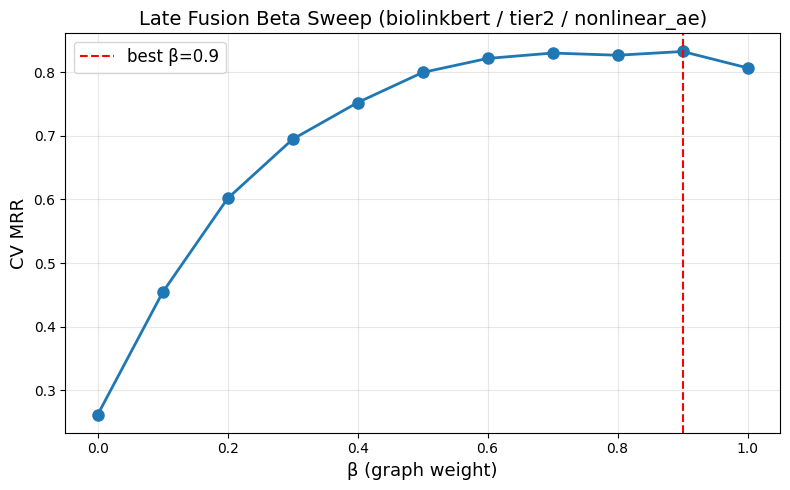

In [ ]:
# Beta sweep visualization
import matplotlib.pyplot as plt

betas = sorted(results["beta_to_mrr"].keys())
mrrs = [results["beta_to_mrr"][b] for b in betas]

plt.figure(figsize=(8, 5))
plt.plot(betas, mrrs, "o-", linewidth=2, markersize=8)
plt.axvline(results["best_beta"], color="red", linestyle="--", label=f"best β={results['best_beta']}")
plt.xlabel("β (graph weight)", fontsize=13)
plt.ylabel("CV MRR", fontsize=13)
plt.title(f"Late Fusion Beta Sweep ({BEST_ENCODER} / {DESC_TIER} / {BEST_PROJECTION})", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"results/beta_sweep_{BEST_ENCODER}_{DESC_TIER}.png", dpi=150)
plt.show()

In [ ]:
# Cold-start stratification
tm = results["test_metrics"]
if "MRR_seen_all" in tm:
    strata_data = {
        "Stratum": ["All seen", "Some seen", "None seen (cold-start)"],
        "MRR": [tm["MRR_seen_all"], tm["MRR_seen_some"], tm["MRR_seen_none"]],
    }
    strata_df = pd.DataFrame(strata_data)
    print("=== Cold-Start Drug Stratification ===")
    print(strata_df.to_string(index=False))

=== Cold-Start Drug Stratification ===
               Stratum      MRR
              All seen 0.228918
             Some seen 0.195962
None seen (cold-start) 0.091899


In [ ]:
# Per-disease results
per_disease_df = results["per_disease_df"]

print(f"Per-disease results: {len(per_disease_df)} diseases")
print(f"\nWorst 5 (by MRR):")
print(per_disease_df.sort_values("MRR").head(5).to_string(index=False))

print(f"\nBest 5 (by MRR):")
print(per_disease_df.sort_values("MRR", ascending=False).head(5).to_string(index=False))

Per-disease results: 108 diseases

Worst 5 (by MRR):
 disease_idx  n_phenotypes  n_true_drugs      MRR  R@10  R@50    AUROC    AUPRC
       31523             4             2 0.000130   0.0   0.0 0.032495 0.000195
       28448            13             1 0.000135   0.0   0.0 0.070639 0.000135
       30612            21             1 0.000222   0.0   0.0 0.434263 0.000222
       33602             2             1 0.000241   0.0   0.0 0.477627 0.000241
       32483            19             1 0.000350   0.0   0.0 0.641151 0.000350

Best 5 (by MRR):
 disease_idx  n_phenotypes  n_true_drugs  MRR     R@10     R@50    AUROC    AUPRC
       27219            73             2  1.0 0.500000 0.500000 0.936329 0.500985
       27361            48            14  1.0 0.214286 0.571429 0.992104 0.269205
       27478            58             1  1.0 1.000000 1.000000 1.000000 1.000000
       27527            19             1  1.0 1.000000 1.000000 1.000000 1.000000
       29993            26            2

---
## 7. Compare description configs in full fusion

Re-run `run_late_fusion_experiment` for three additional description configs and
compare CV MRR + test metrics against the Tier 2 baseline already in `results`:

1. `hybrid` + `BEST_PROJECTION` (nonlinear_ae)
2. `hybrid` + `none`
3. `gpt4o`  + `BEST_PROJECTION` (nonlinear_ae)


In [ ]:
# Sweep additional description configs and store results in a dict.
# `results` from cell 37 is already the Tier 2 + BEST_PROJECTION baseline.
# Each call below reuses the same R-GCN graph scores (s_graph) but recomputes
# s_LLM from a different cached embedding directory, then re-calibrates beta.

BEST_ENCODER = "biolinkbert"
BEST_PROJECTION = "nonlinear_ae"

extra_configs = [
    # {"label": "Hybrid (nonlinear_ae)", "desc_tier": "hybrid", "projection": "nonlinear_ae"},
    {"label": "Hybrid (none)",         "desc_tier": "hybrid", "projection": "none"},
    {"label": "GPT-4o (nonlinear_ae)", "desc_tier": "gpt4o",  "projection": "nonlinear_ae"},
]

results_by_label: dict[str, dict] = {
    f"Tier 2 ({BEST_PROJECTION})": results,   # baseline from cell 37
}

for cfg_extra in extra_configs:
    label = cfg_extra["label"]
    print(f"\n{'='*70}\nRunning fusion: {label}\n{'='*70}")
    cfg = config.copy()
    cfg["desc_tier"]  = cfg_extra["desc_tier"]
    cfg["projection"] = cfg_extra["projection"]
    results_by_label[label] = run_late_fusion_experiment(cfg)


In [16]:
# Side-by-side comparison across all description configs
# CV MRR  = best beta found via 5-fold CV on train diseases
# Test metrics are macro-averaged across the 108 test diseases

metric_keys = [
    "MRR", "R@1", "R@5", "R@10", "R@50",
    "AUROC", "AUPRC",
    "AUROC_balanced_micro", "AUPRC_balanced_micro",
]

comparison_rows = {"Metric": ["best_beta", "CV_MRR"] + metric_keys}
for label, res in results_by_label.items():
    col = [
        f"{res['best_beta']:.2f}",
        f"{res['best_cv_mrr']:.4f}",
    ] + [
        f"{res['test_metrics'].get(m, float('nan')):.4f}"
        for m in metric_keys
    ]
    comparison_rows[label] = col

comparison_df = pd.DataFrame(comparison_rows)
print("=== Late Fusion: description-config comparison (test set, 108 diseases) ===")
print(comparison_df.to_string(index=False))

# Quick CV-MRR ranking (this is what the user actually asked for)
print("\n=== CV MRR ranking (5-fold CV on train diseases, after beta calibration) ===")
cv_rank = sorted(
    ((label, res["best_cv_mrr"], res["best_beta"]) for label, res in results_by_label.items()),
    key=lambda x: x[1], reverse=True,
)
for label, cv, beta in cv_rank:
    print(f"  {label:30s}  CV_MRR={cv:.4f}  (best beta={beta:.2f})")

# Save the comparison so you can refer back without re-running
import json as _json
Path("results/tables").mkdir(parents=True, exist_ok=True)
with open("results/tables/section7_config_comparison.json", "w") as _f:
    _json.dump(
        {
            label: {
                "best_beta": res["best_beta"],
                "best_cv_mrr": res["best_cv_mrr"],
                "test_metrics": res["test_metrics"],
                "pure_graph_metrics": res.get("pure_graph_metrics", {}),
                "pure_llm_metrics": res.get("pure_llm_metrics", {}),
            }
            for label, res in results_by_label.items()
        },
        _f, indent=2,
    )
print("\nSaved -> results/tables/section7_config_comparison.json")


=== Late Fusion: description-config comparison (test set, 108 diseases) ===
              Metric Tier 2 (nonlinear_ae) Hybrid (none) GPT-4o (nonlinear_ae)
           best_beta                  0.90          0.90                  0.90
              CV_MRR                0.8312        0.8267                0.8197
                 MRR                0.2055        0.2043                0.2224
                 R@1                0.0572        0.0567                0.0624
                 R@5                0.1344        0.1287                0.1430
                R@10                0.1744        0.1800                0.1897
                R@50                0.3525        0.3620                0.3661
               AUROC                0.9044        0.9042                0.8855
               AUPRC                0.1541        0.1545                0.1615
AUROC_balanced_micro                0.8183        0.8149                0.8385
AUPRC_balanced_micro                0.8566        0.849

---
## 8. Error Analysis 

Per-disease analyses comparing the four configs from Section 7 to expose where
late fusion helps vs. hurts. All cells share a single `ea_df` built in 8.0.

- **A1** Per-disease Δ MRR vs pure-graph baseline
- **A2** Cold-start stratification across configs (extending cell 41)
- **A3** Phenotype-count stratification across configs
- **A4** Graph vs LLM top-10 disagreement (Jaccard) and its correlation with fusion gain


In [ ]:
# 8.0 — Prep: rebuild per-disease records for graph-only, LLM-only, and fused
# (run_late_fusion_experiment doesn't expose graph/llm scores, so we re-derive
# them here; the heavy R-GCN encode happens once and is cached as node_embs)

import torch
from src.data.primekg_loader import (
    mask_test_diseases, build_pyg_graph, build_supervision_maps
)
from src.evaluation.late_fusion_eval import (
    load_graph_scores, load_llm_scores, _build_drug_degree,
    _extract_state_dict, _infer_arch_from_state_dict, _pick_num_heads,
)
from src.models.cross_attention_scorer import PhenoDrugModel
from src.models.fusion import normalize_scores
from src.evaluation.metrics import reciprocal_rank, recall_at_k

# ── Build supervision (test_disease_to_drugs is needed; cell 12 only exposed train) ──
supervision_ea = build_supervision_maps(
    kg_df, nodes_df, train_diseases, test_diseases, train_pairs, test_pairs
)
test_disease_to_drugs_ea = supervision_ea["test_disease_to_drugs"]
drug_degree_ea = _build_drug_degree(train_pairs)

# ── Build masked training subgraph + load model with arch inference ──
kg_train_ea = mask_test_diseases(kg_df, test_diseases)
edge_index_ea, edge_type_ea, num_relations_ea, _ = build_pyg_graph(kg_train_ea, DEVICE)
ckpt_obj = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
sd = _extract_state_dict(ckpt_obj)
arch = _infer_arch_from_state_dict(sd)
model_ea = PhenoDrugModel(
    num_nodes=len(nodes_df),
    num_relations=num_relations_ea,
    hidden_dim=arch["hidden_dim"],
    num_bases=arch.get("num_bases", 10),
    num_layers=arch["num_layers"],
    num_heads=_pick_num_heads(arch["hidden_dim"], 4),
    dropout=0.2,
).to(DEVICE)
model_ea.load_state_dict(sd, strict=True)
print(f"Loaded model with arch={arch}")

# ── Score test diseases under graph alone (one R-GCN forward + chunked scoring) ──
print("\nComputing graph_scores on test diseases...")
graph_scores_ea = load_graph_scores(
    model_ea, edge_index_ea, edge_type_ea,
    list(test_diseases), disease_to_phenotypes, drug_indices_arr, DEVICE,
)

# ── Score test diseases under each config's LLM embeddings ──
configs_ea = {
    "Tier 2 (nonlinear_ae)": ("biolinkbert", "tier2",  "nonlinear_ae"),
    "Hybrid (none)":         ("biolinkbert", "hybrid", "none"),
    "GPT-4o (nonlinear_ae)": ("biolinkbert", "gpt4o",  "nonlinear_ae"),
}
llm_scores_by_label_ea: dict[str, dict] = {}
for label, (enc, tier, proj) in configs_ea.items():
    drug_p  = f"data/embeddings/{enc}/{tier}/{proj}/drug_embeddings.pt"
    pheno_p = f"data/embeddings/{enc}/{tier}/{proj}/phenotype_embeddings.pt"
    llm_scores_by_label_ea[label] = load_llm_scores(
        list(test_diseases), disease_to_phenotypes,
        drug_p, pheno_p,
        drug_indices_arr=drug_indices_arr,
    )

# ── Per-disease record helper ──
def _per_disease_records(scores_dict, label):
    rows = []
    for d_idx, scores in scores_dict.items():
        true_drugs = list(test_disease_to_drugs_ea.get(d_idx, []))
        if not true_drugs:
            continue
        ranked = drug_indices_arr[np.argsort(-scores)].tolist()
        n_seen = sum(1 for d in true_drugs if drug_degree_ea.get(d, 0) > 0)
        rows.append({
            "disease_idx": d_idx,
            "label": label,
            "n_phenotypes": len(disease_to_phenotypes.get(d_idx, [])),
            "n_true_drugs": len(true_drugs),
            "n_seen_true_drugs": n_seen,
            "seen_ratio": n_seen / len(true_drugs),
            "MRR": reciprocal_rank(ranked, true_drugs),
            "R@10": recall_at_k(ranked, true_drugs, 10),
            "top10": tuple(ranked[:10]),
        })
    return pd.DataFrame(rows)

# Build the master ea_df: one row per (disease, label) combination
records = [_per_disease_records(graph_scores_ea, "Graph (β=1)")]
for label, llm_scores in llm_scores_by_label_ea.items():
    records.append(_per_disease_records(llm_scores, f"{label} — LLM only (β=0)"))
    # Fused at this config's calibrated best β
    best_beta_lbl = results_by_label[label]["best_beta"]
    fused_dict = {}
    for d_idx in test_diseases:
        if d_idx not in graph_scores_ea or d_idx not in llm_scores:
            continue
        s_g = normalize_scores(graph_scores_ea[d_idx], "minmax")
        s_l = normalize_scores(llm_scores[d_idx],     "minmax")
        fused_dict[d_idx] = best_beta_lbl * s_g + (1 - best_beta_lbl) * s_l
    records.append(_per_disease_records(fused_dict, f"{label} — Fused (β={best_beta_lbl:.2f})"))

ea_df = pd.concat(records, ignore_index=True)
print(f"\nBuilt ea_df: {len(ea_df)} rows × {len(ea_df.columns)} cols")
print(f"Labels: {ea_df['label'].unique().tolist()}")
print(ea_df.head(2))


In [ ]:
# 8.1 — A1: Per-disease Δ MRR (fused − pure-graph)
# Where exactly is fusion winning over the pure-graph baseline?
import matplotlib.pyplot as plt

graph_mrr_per_disease = (
    ea_df[ea_df["label"] == "Graph (β=1)"]
    .set_index("disease_idx")["MRR"]
)

fused_labels = [l for l in ea_df["label"].unique() if " — Fused" in l]
fig, axes = plt.subplots(1, len(fused_labels), figsize=(5 * len(fused_labels), 4), sharey=True)
if len(fused_labels) == 1: axes = [axes]

a1_summary = []
for ax, label in zip(axes, fused_labels):
    fused_mrr = (
        ea_df[ea_df["label"] == label]
        .set_index("disease_idx")["MRR"]
    )
    delta = (fused_mrr - graph_mrr_per_disease).dropna()
    n_win, n_lose, n_same = (delta > 1e-6).sum(), (delta < -1e-6).sum(), (abs(delta) <= 1e-6).sum()
    ax.hist(delta.values, bins=30, edgecolor="black", alpha=0.75)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{label.split(' — ')[0]}\nmean Δ={delta.mean():+.4f}", fontsize=11)
    ax.set_xlabel("Δ MRR  (fused − graph)")
    ax.grid(True, alpha=0.3)
    a1_summary.append({
        "config": label.split(" — ")[0],
        "mean_Δ": delta.mean(),
        "median_Δ": delta.median(),
        "n_better": int(n_win),
        "n_worse": int(n_lose),
        "n_unchanged": int(n_same),
        "max_gain": delta.max(),
        "max_loss": delta.min(),
    })
axes[0].set_ylabel("# test diseases")
plt.tight_layout()
plt.savefig("results/A1_per_disease_delta.png", dpi=120)
plt.show()

print("\n=== A1: Δ MRR vs pure-graph baseline (per disease) ===")
print(pd.DataFrame(a1_summary).to_string(index=False))

# Top-5 disease-level winners and losers under each config
print("\n=== Biggest fusion gains / losses per config ===")
for label in fused_labels:
    fused_mrr = ea_df[ea_df["label"] == label].set_index("disease_idx")["MRR"]
    delta = (fused_mrr - graph_mrr_per_disease).dropna().sort_values()
    name_map = nodes_df.set_index("node_index")["node_name"].to_dict()
    print(f"\n--- {label} ---")
    print("  Top-5 GAINS  (graph→fused):")
    for d_idx, dv in delta.tail(5)[::-1].items():
        gm = graph_mrr_per_disease.get(d_idx, float('nan'))
        fm = fused_mrr.get(d_idx, float('nan'))
        print(f"    {name_map.get(d_idx, d_idx):40s}  graph={gm:.3f} → fused={fm:.3f}  (Δ={dv:+.3f})")
    print("  Top-5 LOSSES (graph→fused):")
    for d_idx, dv in delta.head(5).items():
        gm = graph_mrr_per_disease.get(d_idx, float('nan'))
        fm = fused_mrr.get(d_idx, float('nan'))
        print(f"    {name_map.get(d_idx, d_idx):40s}  graph={gm:.3f} → fused={fm:.3f}  (Δ={dv:+.3f})")


In [ ]:
# 8.2 — A2: Cold-start stratification across all configs
# Bin test diseases by what fraction of their true drugs were SEEN in training
# (drug_degree > 0 ⇒ "seen"). Report MRR per (config, stratum).
def _bin_seen_ratio(r):
    if r == 0:    return "none (cold-start)"
    if r < 1.0:   return "some"
    return "all"

ea_df["seen_bin"] = ea_df["seen_ratio"].apply(_bin_seen_ratio)

# Pivot: rows = config label, cols = stratum
labels_wanted = (
    ["Graph (β=1)"]
    + [l for l in ea_df["label"].unique() if " — LLM only" in l]
    + [l for l in ea_df["label"].unique() if " — Fused" in l]
)
sub = ea_df[ea_df["label"].isin(labels_wanted)].copy()

a2 = (
    sub.groupby(["label", "seen_bin"])["MRR"].mean().unstack("seen_bin")
       .reindex(labels_wanted)
       .reindex(columns=["all", "some", "none (cold-start)"])
)
counts = (
    sub[sub["label"] == "Graph (β=1)"]
       .groupby("seen_bin").size()
       .reindex(["all", "some", "none (cold-start)"])
)

print("=== A2: MRR by cold-start stratum (rows=config, cols=stratum) ===")
print(f"Stratum sizes (test diseases): {counts.to_dict()}")
print(a2.to_string(float_format="%.4f"))

# Δ within each stratum: how much does fusion lift cold-start specifically?
print("\n=== Lift over Graph (β=1) within each stratum ===")
delta_a2 = a2.subtract(a2.loc["Graph (β=1)"], axis="columns")
print(delta_a2.drop(index="Graph (β=1)").to_string(float_format="%+.4f"))


In [ ]:
# 8.3 — A3: Phenotype count stratification
# CLAUDE.md flagged phenotype sparsity as a known failure mode (1-3 phenos: MRR 0.13).
# Does LLM signal help more when phenotype evidence is sparse?
ea_df["pheno_bin"] = pd.cut(
    ea_df["n_phenotypes"],
    bins=[0, 3, 10, 30, 1000],
    labels=["1-3", "4-10", "11-30", "30+"],
)

a3 = (
    ea_df[ea_df["label"].isin(labels_wanted)]
        .groupby(["label", "pheno_bin"], observed=True)["MRR"].mean()
        .unstack("pheno_bin")
        .reindex(labels_wanted)
        .reindex(columns=["1-3", "4-10", "11-30", "30+"])
)
counts3 = (
    ea_df[ea_df["label"] == "Graph (β=1)"]
        .groupby("pheno_bin", observed=True).size()
        .reindex(["1-3", "4-10", "11-30", "30+"])
)
print("=== A3: MRR by phenotype-count bin (rows=config, cols=bin) ===")
print(f"Stratum sizes (test diseases): {counts3.to_dict()}")
print(a3.to_string(float_format="%.4f"))

print("\n=== Lift over Graph (β=1) within each phenotype bin ===")
print(a3.subtract(a3.loc["Graph (β=1)"], axis="columns")
        .drop(index="Graph (β=1)").to_string(float_format="%+.4f"))


In [ ]:
# 8.4 — A4: Graph vs LLM top-10 disagreement (Jaccard) and its link to fusion gain
# Hypothesis: when graph and LLM TOP-10 lists barely overlap, fusion should help more
# (signals are complementary). When they overlap heavily, fusion is redundant.
import matplotlib.pyplot as plt

graph_top10 = ea_df[ea_df["label"] == "Graph (β=1)"].set_index("disease_idx")["top10"]

print("=== A4: Top-10 Jaccard(graph, LLM) and its correlation with fusion gain ===")
fig, axes = plt.subplots(1, len(configs_ea), figsize=(5 * len(configs_ea), 4), sharey=True)
if len(configs_ea) == 1: axes = [axes]

a4_summary = []
for ax, (label, _) in zip(axes, configs_ea.items()):
    llm_lbl   = f"{label} — LLM only (β=0)"
    fused_lbl = next(l for l in fused_labels if l.startswith(label))
    llm_top10   = ea_df[ea_df["label"] == llm_lbl  ].set_index("disease_idx")["top10"]
    fused_mrr   = ea_df[ea_df["label"] == fused_lbl].set_index("disease_idx")["MRR"]

    rows = []
    for d_idx in graph_top10.index:
        if d_idx not in llm_top10.index or d_idx not in fused_mrr.index:
            continue
        gset, lset = set(graph_top10[d_idx]), set(llm_top10[d_idx])
        jac = len(gset & lset) / max(len(gset | lset), 1)
        gm = graph_mrr_per_disease.get(d_idx, float('nan'))
        rows.append({"jaccard": jac, "delta": fused_mrr[d_idx] - gm})
    df = pd.DataFrame(rows)
    rho = df.corr(method="spearman").loc["jaccard", "delta"]

    ax.scatter(df["jaccard"], df["delta"], alpha=0.5, s=22)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{label}\nmean Jaccard={df['jaccard'].mean():.3f}, ρ={rho:+.2f}", fontsize=11)
    ax.set_xlabel("Jaccard(top10 graph, top10 LLM)")
    ax.grid(True, alpha=0.3)

    a4_summary.append({
        "config": label,
        "mean_jaccard": df["jaccard"].mean(),
        "median_jaccard": df["jaccard"].median(),
        "frac_overlap=0": float((df["jaccard"] == 0).mean()),
        "spearman_jacc_vs_Δ": rho,
    })
axes[0].set_ylabel("Δ MRR (fused − graph)")
plt.tight_layout()
plt.savefig("results/A4_jaccard_vs_delta.png", dpi=120)
plt.show()

print(pd.DataFrame(a4_summary).to_string(index=False, float_format="%.4f"))
print("""
Interpretation guide:
  • Low mean Jaccard → graph and LLM make very different predictions
    → fusion has room to combine signals, expect positive Δ
  • High mean Jaccard → signals redundant; fusion mostly noise
  • Negative Spearman ρ → fusion gain larger when overlap is small
    (the desired pattern for late fusion to be worth doing)
""")
